# Random Forest Regression for Daily Failure Forecasting
This notebook uses a Random Forest model to forecast the number of daily failures, using the same data preparation as the Poisson regression workflow.

### TO DO

replace observed temp by hourly forecast data

add soil moisture

add precip

correct the forecast for Milan

add morning ramp effect

separate into zones with primary cabins

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import datetime as dt
import pvlib
import warnings
warnings.filterwarnings('ignore')

In [2]:
def get_guasti(fname, dstart, dend):

    # Load the dataset
    colnames = ['Data di guasto','OdL padre','Scatto','Rete','Impianto','Cavo',
                'Tratto cavo / da cabina elemento di rete presunto sede di guasto',
                'Tipo','da cabina','a cabina','Numero Nodo GIS - Solo rete 23 Kv giunti 12/20',
                'Priorità','Criticità','Fase lavorativa','Ricerca guasto','Impresa scavo','Riparazione',
                'Indirizzo dell\'intervento','Causa accertata','Intervento eseguito','Data rientro',
                'Note esercizio','Note fasi lavorative','Mese guasto','Mese riparazione','Anno',
                'Raggruppamento causa accertata','Origine','Agregazione impianto','verifica data']
    dataset = pd.read_excel(fname, sheet_name='Monitoraggio', header=None, names=colnames)

    # Convert the 'Data di guasto' column to datetime
    dataset['Data di guasto'] = pd.to_datetime(dataset['Data di guasto'], format='%d/%m/%Y', errors='coerce')
    dataset['Mese guasto'] = pd.to_datetime(dataset['Mese guasto'], format='%B', errors='coerce').dt.month

    # localize to Europe/Rome
    dataset['Data di guasto'] = dataset['Data di guasto'].dt.tz_localize('Europe/Rome')

    # filter 
    dataset = dataset[(dataset['Data di guasto'].dt.date >=dstart) & (dataset['Data di guasto'].dt.date <= dend)]

    # fill missing values in 'Causa accertata' with 'NON ACCERTATA'
    dataset['Causa accertata'] = dataset['Causa accertata'].fillna('NON ACCERTATA')

    # remove some causes
    irrelevant_causes=['NO GUASTO', 'COMPETENZA ENEL', 'PROVA DI TENSIONE OK', 'RIFACIMENTO GIUNTI 20KV']
    dataset = dataset[~dataset['Causa accertata'].isin(irrelevant_causes)]

    # group causes
    groupcause = {'joint':['AG AUTORETRAIBILE 20kV','AG TERMO-RESTRINGENTI 20kV','AG 9kV (miscela a caldo)','AG BICOMPONENTE 9kV (miscela a freddo)',
                           'AG 23kV (vecchio tipo)','AG CAVO PRECORDATO','AG RESINA','AG AUTORETRAIBILE 30kV', 'AG AUTORETR. 30KV + CELLA'],
                  'cable':['CAVO DETERIORATO','CAVO DANNEGGIATO','CAVO INTACCATO', 'CAVO DETERIORATO + CELLA LINEA'],
                  'cabin':['CABINA','TERMINALE RAICHEM','TERMINALE VETRO','CELLA LINEA','CELLA UTENTE','TERMINALE SILICONICO','TRASFORMATORE','2962 CELLA',
                           'TERMINALI + CELLA LINEA','TERMINALI ','TERMINALI','CELLA TRAFO','TERMINALE','TERMINALE + CELLA LINEA', 'TERMINALE+CELLA',
                           'CELLA TRAFO + CELLA CONGIUNTORE'],
                  'other':['DANNI', 'DANNI DA INCENDIO','SEZIONATORE A PALO', 'NON ACCERTATA']
                  }
    dataset['Causegroup'] = dataset['Causa accertata'].apply(lambda x: 'cable' if x in groupcause['cable'] else ('cabin' if x in groupcause['cabin'] else ('joint' if x in groupcause['joint'] else 'other')))
    dataset['Causegroup'] = dataset['Causegroup'].astype('category')

    print(dataset['Causegroup'].unique())

    return dataset

In [3]:
guasti_2012_2024 = get_guasti('pri_raw_pri_2023-12-11.xlsx', dt.date(2012, 1, 1), dt.date(2024, 12, 31))

['cable', 'joint', 'cabin', 'other']
Categories (4, object): ['cabin', 'cable', 'joint', 'other']


In [ ]:
def get_hist_temperature(fname):

    # Load the dataset
    dataset = pd.read_csv(fname)

    # Convert the 'Data-Ora' column to datetime and change names
    dataset['Data-Ora'] = pd.to_datetime(dataset['Data-Ora'])
    dataset['Data-Ora'] = dataset['Data-Ora'].dt.tz_localize('Europe/Rome')
    dataset.rename(columns={'Data-Ora':'VALID_DATE', 'Valore Medio Giornaliero':'T_mean', ' Minimo Valore Medio Orario':'T_min', ' Massimo Valore Medio Orario':'T_max'}, inplace=True)

    # replace -999.0 with np.nan
    dataset['T_mean'] = dataset['T_mean'].replace(-999.0, np.nan)
    dataset['T_min'] = dataset['T_min'].replace(-999.0, np.nan)
    dataset['T_max'] = dataset['T_max'].replace(-999.0, np.nan)

    # drop rows with nan values
    dataset = dataset.dropna()

    return dataset

temp_brera = get_hist_temperature(r'brera_station\brera_temp_2012_2024.csv')


In [11]:
# --- Data Preparation Functions (reuse from Poisson regression workflow) ---
def prepare_data(temp, guasti, test_size=2/11):
    """ Prepare the data for the analysis and split into train/test sets """
    guasti_day = guasti['Data di guasto'].dt.date.value_counts().sort_index()
    idx = pd.date_range(guasti_day.index.min(), guasti_day.index.max())
    guasti_day = guasti_day.reindex(idx, fill_value=0)
    guasti_day = guasti_day.astype(int)
    guasti_day.index = guasti_day.index.tz_localize('Europe/Rome')
    data = pd.merge(temp, guasti_day, left_on='VALID_DATE', right_index=True, how='inner')
    data.rename(columns={'count':'Failures'}, inplace=True)
    data.set_index('VALID_DATE', inplace=True)
    
    # Lagged features
    for lag in range(1, 6):
        data[f'T_mean_D-{lag}'] = data['T_mean'].shift(lag)
        data[f'T_min_D-{lag}'] = data['T_min'].shift(lag)
        data[f'T_max_D-{lag}'] = data['T_max'].shift(lag)
    data['Failures_D-1'] = data['Failures'].shift(1)
    data['Failures_D-14'] = data['Failures'].rolling(window=14).sum()
    data['Failures_annual'] = data['Failures'].rolling(window=365).sum()
    
    # Solar elevation
    latitude, longitude = 45.47, 9.19
    times = data.index + pd.Timedelta(hours=12)
    solpos = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    solpos.index = solpos.index - pd.Timedelta(hours=12)
    data['elevation'] = solpos['elevation']
    
    # T_mean^4
    data['T_mean4'] = data['T_mean']**4
    data = data.dropna()

    # accumulated temperature (related to lagged soil temperature)
    data['T_mean_accumulated_30D'] = data['T_mean'].rolling(window=30).sum()
    data['T_mean_accumulated_5D'] = data['T_mean'].rolling(window=5).sum()

    # heatwave number, how many heatwaves in the last year. One heatwace is a serie of days with T_mean > 32C
    data['heatwave'] = (data['T_mean'] > 32).astype(int)  # Example threshold for heatwave
    # group consecutive days into the first day of the heatwave
    for i in range(1, len(data)):
        if data['heatwave'].iloc[i] == 1 and data['heatwave'].iloc[i-1] == 0:
            data['heatwave'].iloc[i] = 1
        elif data['heatwave'].iloc[i] == 1 and data['heatwave'].iloc[i-1] == 1:
            data['heatwave'].iloc[i] = 0
    data['heatwave_annual'] = data['heatwave'].rolling(window=365).sum()
    data = data.drop(columns=['heatwave'])
    print('number of heatwaves in the last year:', data['heatwave_annual'].max())
    
    
    # Feature selection
    feature_cols = [
        'elevation', 
        'T_mean', 
        'T_mean_D-1', 
        # 'T_mean_D-2', 
        # 'T_mean_D-3', 
        # 'T_mean_D-4', 
        # 'T_mean_D-5',
        'T_min', 
        'T_min_D-1', 
        # 'T_min_D-2', 
        # 'T_min_D-3', 
        # 'T_min_D-4', 
        # 'T_min_D-5',
        'T_max', 
        'T_max_D-1', 
        # 'T_max_D-2', 
        # 'T_max_D-3', 
        # 'T_max_D-4', 
        # 'T_max_D-5',
        'T_mean4', 
        'Failures_D-1', 
        'Failures_D-14', 
        'Failures_annual',
        'T_mean_accumulated_30D',
        # 'T_mean_accumulated_5D',
        #'heatwave_annual'
    ]
    X = data[feature_cols].values
    y = data['Failures'].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    n = len(X_scaled)
    split_idx = int(n * (1 - test_size))
    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    dates_train = data.index[:split_idx]
    dates_test = data.index[split_idx:]
    return X_train, X_test, y_train, y_test, dates_train, dates_test, feature_cols

In [12]:
# --- Prepare data ---
X_train, X_test, y_train, y_test, dates_train, dates_test, feature_cols = prepare_data(temp_brera, guasti_2012_2024)

number of heatwaves in the last year: 2.0


In [13]:
# --- Fit Random Forest ---
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [14]:
# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE: {mae:.3f}")
print(f"Test R2: {r2:.3f}")

Test RMSE: 3.126
Test MAE: 1.899
Test R2: 0.526


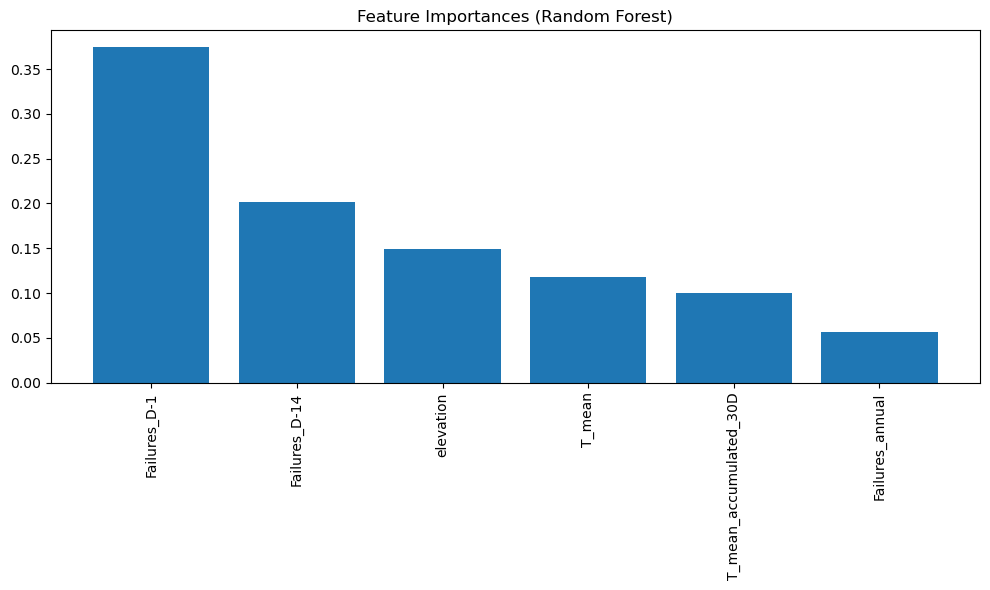

In [9]:
# --- Feature Importance Plot ---
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

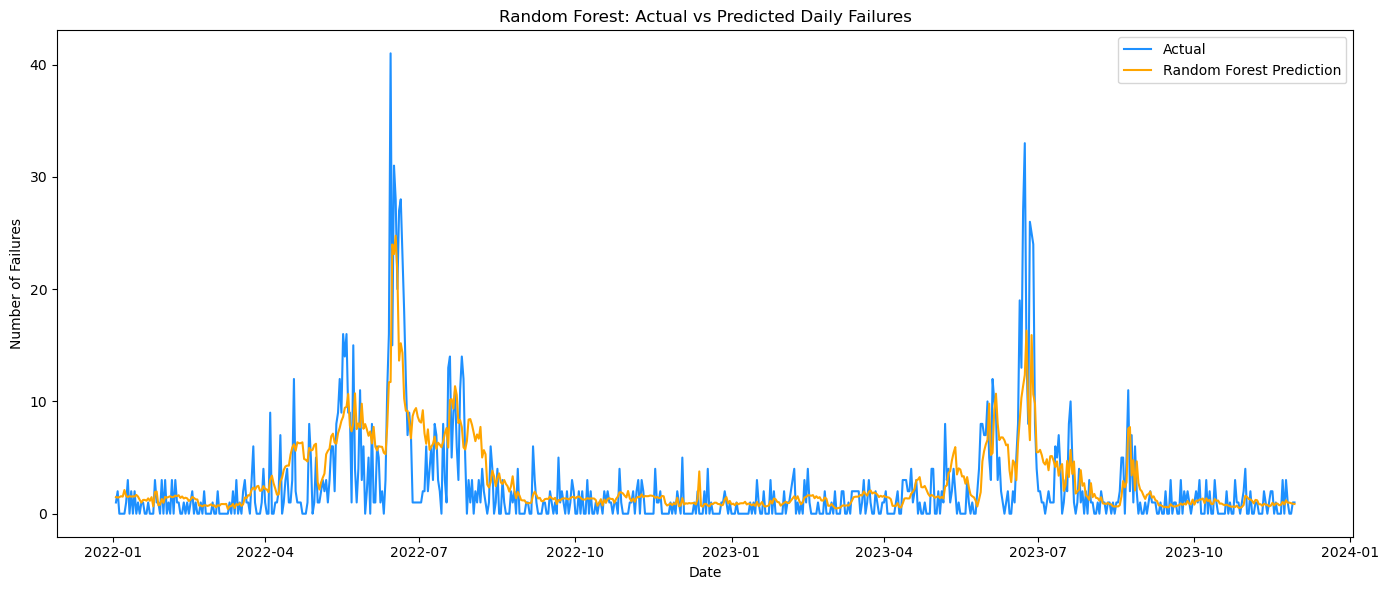

In [10]:
# --- Prediction vs Actual Plot ---
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_test, label='Actual', color='dodgerblue')
plt.plot(dates_test, y_pred, label='Random Forest Prediction', color='orange')
plt.xlabel('Date')
plt.ylabel('Number of Failures')
plt.title('Random Forest: Actual vs Predicted Daily Failures')
plt.legend()
plt.tight_layout()
plt.show()